# Tech Challenge 5 — Modelagem de Ameaças com IA (STRIDE)

**Luís Felipe Alves — RM: 363734**


## Objetivo
- Representar arquiteturas em JSON (componentes + fluxos)
- Aplicar STRIDE automaticamente
- Gerar relatórios em Markdown para AWS e Azure


## 1) Motor STRIDE


In [12]:
from __future__ import annotations
from datetime import datetime
import json

STRIDE_NAMES = {
  "S":"Spoofing",
  "T":"Tampering",
  "R":"Repudiation",
  "I":"Information Disclosure",
  "D":"Denial of Service",
  "E":"Elevation of Privilege"
}

STRIDE_BY_COMPONENT = {
  "user": ["S","R"],
  "identity_provider": ["S","T","R","I","E","D"],

  "cdn": ["T","I","D"],
  "waf": ["D","T"],
  "ddos_protection": ["D"],

  "load_balancer": ["D","T","S"],
  "api_gateway": ["S","T","R","I","D","E"],
  "web_app": ["S","T","R","I","D","E"],
  "app_server": ["S","T","R","I","D","E"],
  "function": ["S","T","R","I","D","E"],

  "database": ["T","R","I","D","E"],
  "cache": ["T","I","D"],
  "filesystem": ["T","I","R"],
  "queue": ["T","R","D"],
  "email_service": ["S","T","R","I"],

  "monitoring": ["R","I"],
  "logging_audit": ["R","I","T"],
  "kms": ["S","T","I"],
  "backup": ["T","R","I"],
  "cloud_service": ["S","T","R","I","D","E"],

  "saas": ["S","T","R","I","D","E"],
  "rest_service": ["S","T","R","I","D","E"],
  "soap_service": ["S","T","R","I","D","E"],

  "network_boundary": ["S","T","I","D"],
  "subnet_public": ["I","D","T"],
  "subnet_private": ["T","I"]
}

MITIGATIONS_BY_STRIDE = {
  "S": [
    "Autenticação forte (OIDC/OAuth2), MFA quando aplicável",
    "mTLS entre serviços internos (quando possível)"
  ],
  "T": [
    "Validação de entrada (schema validation) e sanitização",
    "Princípio do menor privilégio para escrita/alteração"
  ],
  "R": [
    "Logs imutáveis e trilhas de auditoria com correlação de IDs",
    "Monitoramento e alertas para ações sensíveis"
  ],
  "I": [
    "TLS obrigatório em trânsito e criptografia em repouso (KMS)",
    "RBAC/ABAC + segmentação de rede"
  ],
  "D": [
    "Rate limiting, throttling, circuit breaker",
    "Auto scaling e proteção anti-DDoS"
  ],
  "E": [
    "RBAC/least privilege + separação de funções (SoD)",
    "Revisão de permissões administrativas e hardening"
  ]
}

BASE_SEVERITY = {"S":2,"T":3,"R":2,"I":3,"D":3,"E":4}
CRITICAL_TYPES = {"database","identity_provider","kms"}

def risk_score(threat_code: str, component_type: str, boundary_name: str | None):
    score = BASE_SEVERITY.get(threat_code, 2)
    if component_type in CRITICAL_TYPES:
        score += 2
    if boundary_name and "internet" in boundary_name.lower():
        score += 2
    return min(score, 10)

def risk_label(score: int):
    if score >= 8: return "ALTO"
    if score >= 5: return "MÉDIO"
    return "BAIXO"

## 2) Funções


In [13]:
def validate_architecture_schema(data: dict):
    required_top = {"system_name","components","flows","trust_boundaries","assumptions"}
    missing = required_top - set(data.keys())
    if missing:
        raise ValueError(f"JSON inválido. Campos faltando: {missing}")

    comp_ids = set()
    for c in data["components"]:
        for k in ["id","name","type"]:
            if k not in c:
                raise ValueError("Cada componente precisa ter: id, name, type")
        if c["id"] in comp_ids:
            raise ValueError(f"ID de componente duplicado: {c['id']}")
        comp_ids.add(c["id"])

    for f in data["flows"]:
        for k in ["id","source_id","target_id"]:
            if k not in f:
                raise ValueError("Cada flow precisa ter: id, source_id, target_id")
        if f["source_id"] not in comp_ids or f["target_id"] not in comp_ids:
            raise ValueError(f"Flow com source_id/target_id inválido: {f.get('id')}")

def infer_boundary_for_component(component_id: str, flows: list[dict]) -> str | None:
    for fl in flows:
        if fl.get("target_id") == component_id and fl.get("trust_boundary"):
            return fl["trust_boundary"]
    return None

def threats_for_component(component: dict, flows: list[dict]):
    ctype = component["type"]
    threats = STRIDE_BY_COMPONENT.get(ctype, ["S","T","R","I","D","E"])
    boundary = infer_boundary_for_component(component["id"], flows)

    items = []
    for t in threats:
        score = risk_score(t, ctype, boundary)
        items.append({
            "stride": t,
            "stride_name": STRIDE_NAMES[t],
            "risk_score": score,
            "risk_level": risk_label(score),
            "mitigations": MITIGATIONS_BY_STRIDE[t]
        })
    return sorted(items, key=lambda x: x["risk_score"], reverse=True)

def build_report_md(data: dict):
    validate_architecture_schema(data)
    ts = datetime.now().strftime("%Y-%m-%d %H:%M")

    lines = []
    lines.append(f"# Relatório de Modelagem de Ameaças (STRIDE) — {data.get('system_name','Sistema')}")
    lines.append(f"\n_Gerado em: {ts}_\n")

    lines.append("## 1. Visão geral")
    lines.append("Entrada: diagrama (imagem) → JSON → STRIDE por regras determinísticas (Python).")

    lines.append("\n## 2. Componentes detectados")
    for c in data["components"]:
        provider = c.get("provider")
        zone = c.get("zone")
        meta = []
        if provider: meta.append(f"provider={provider}")
        if zone: meta.append(f"zone={zone}")
        meta_txt = (" (" + ", ".join(meta) + ")") if meta else ""
        lines.append(f"- **{c['name']}** — `{c['type']}`{meta_txt}")

    lines.append("\n## 3. Fluxos identificados")
    for f in data["flows"]:
        proto = f.get("protocol") or "N/A"
        tb = f.get("trust_boundary") or "N/A"
        lines.append(f"- `{f['id']}`: **{f['source_id']} → {f['target_id']}** | protocolo: {proto} | fronteira: {tb}")

    lines.append("\n## 4. Ameaças por componente (STRIDE)")
    for c in data["components"]:
        lines.append(f"\n### {c['name']} (`{c['type']}`)")
        for t in threats_for_component(c, data["flows"]):
            lines.append(f"- **{t['stride_name']} ({t['stride']})** — Risco: **{t['risk_level']}** (score {t['risk_score']}/10)")
            for m in t["mitigations"][:2]:
                lines.append(f"  - Mitigação: {m}")

    lines.append("\n## 5. Assumptions / Limitações")
    for a in (data.get('assumptions') or []):
        lines.append(f"- {a}")

    return "\n".join(lines)

## 3) Arquitetura 1


In [14]:
aws_json_str = r'''{
  "system_name": "Arquitetura 1 (AWS) — SEI/SIP",
  "components": [
    {
      "id": "c1",
      "name": "Usuários SEI",
      "type": "user",
      "provider": null,
      "zone": null,
      "notes": null
    },
    {
      "id": "c2",
      "name": "AWS Shield",
      "type": "ddos_protection",
      "provider": "AWS",
      "zone": null,
      "notes": "Proteção DDoS"
    },
    {
      "id": "c3",
      "name": "Amazon CloudFront",
      "type": "cdn",
      "provider": "AWS",
      "zone": null,
      "notes": "Edge CDN"
    },
    {
      "id": "c4",
      "name": "AWS WAF",
      "type": "waf",
      "provider": "AWS",
      "zone": null,
      "notes": "Filtro HTTP(S)"
    },
    {
      "id": "c5",
      "name": "VPC",
      "type": "network_boundary",
      "provider": "AWS",
      "zone": "sa-east-1 (São Paulo)",
      "notes": null
    },
    {
      "id": "c6",
      "name": "Public Subnet A",
      "type": "subnet_public",
      "provider": "AWS",
      "zone": "Availability Zone A",
      "notes": null
    },
    {
      "id": "c7",
      "name": "Public Subnet B",
      "type": "subnet_public",
      "provider": "AWS",
      "zone": "Availability Zone B",
      "notes": null
    },
    {
      "id": "c8",
      "name": "Public Subnet C",
      "type": "subnet_public",
      "provider": "AWS",
      "zone": "Availability Zone C",
      "notes": null
    },
    {
      "id": "c9",
      "name": "Application Load Balancer A",
      "type": "load_balancer",
      "provider": "AWS",
      "zone": "Availability Zone A",
      "notes": "Public"
    },
    {
      "id": "c10",
      "name": "Application Load Balancer B",
      "type": "load_balancer",
      "provider": "AWS",
      "zone": "Availability Zone B",
      "notes": "Public"
    },
    {
      "id": "c11",
      "name": "Application Load Balancer C",
      "type": "load_balancer",
      "provider": "AWS",
      "zone": "Availability Zone C",
      "notes": "Public"
    },
    {
      "id": "c12",
      "name": "SEI/SIP App Server A",
      "type": "app_server",
      "provider": "AWS",
      "zone": "Availability Zone A",
      "notes": "Auto Scaling"
    },
    {
      "id": "c13",
      "name": "SEI/SIP App Server B",
      "type": "app_server",
      "provider": "AWS",
      "zone": "Availability Zone B",
      "notes": "Auto Scaling"
    },
    {
      "id": "c14",
      "name": "SEI/SIP App Server C",
      "type": "app_server",
      "provider": "AWS",
      "zone": "Availability Zone C",
      "notes": "Auto Scaling"
    },
    {
      "id": "c15",
      "name": "Solr",
      "type": "app_server",
      "provider": "AWS",
      "zone": "Availability Zone C",
      "notes": "Auto Scaling"
    },
    {
      "id": "c16",
      "name": "Amazon RDS (Primary)",
      "type": "database",
      "provider": "AWS",
      "zone": "Multi-AZ",
      "notes": null
    },
    {
      "id": "c17",
      "name": "Amazon RDS (Secondary)",
      "type": "database",
      "provider": "AWS",
      "zone": "Multi-AZ",
      "notes": "Read replica/standby"
    },
    {
      "id": "c18",
      "name": "Amazon ElastiCache (Memcached)",
      "type": "cache",
      "provider": "AWS",
      "zone": "Multi-AZ",
      "notes": null
    },
    {
      "id": "c19",
      "name": "Amazon Elastic File System (NFS)",
      "type": "filesystem",
      "provider": "AWS",
      "zone": "Multi-AZ",
      "notes": null
    },
    {
      "id": "c20",
      "name": "AWS CloudTrail",
      "type": "logging_audit",
      "provider": "AWS",
      "zone": null,
      "notes": null
    },
    {
      "id": "c21",
      "name": "AWS Key Management Service",
      "type": "kms",
      "provider": "AWS",
      "zone": null,
      "notes": null
    },
    {
      "id": "c22",
      "name": "AWS Backup",
      "type": "backup",
      "provider": "AWS",
      "zone": null,
      "notes": null
    },
    {
      "id": "c23",
      "name": "Amazon CloudWatch",
      "type": "monitoring",
      "provider": "AWS",
      "zone": null,
      "notes": null
    },
    {
      "id": "c24",
      "name": "Amazon Simple Email Service (SES)",
      "type": "email_service",
      "provider": "AWS",
      "zone": null,
      "notes": null
    }
  ],
  "flows": [
    {
      "id": "f1",
      "source_id": "c1",
      "target_id": "c2",
      "protocol": "HTTPS",
      "data": "Acesso web",
      "trust_boundary": "Internet ↔ AWS"
    },
    {
      "id": "f2",
      "source_id": "c2",
      "target_id": "c3",
      "protocol": "HTTPS",
      "data": "Tráfego web",
      "trust_boundary": "Internet ↔ AWS"
    },
    {
      "id": "f3",
      "source_id": "c3",
      "target_id": "c4",
      "protocol": "HTTPS",
      "data": "HTTP(S)",
      "trust_boundary": "Internet ↔ AWS"
    },
    {
      "id": "f4",
      "source_id": "c4",
      "target_id": "c9",
      "protocol": "HTTPS",
      "data": "HTTP(S)",
      "trust_boundary": "Internet ↔ AWS"
    },
    {
      "id": "f5",
      "source_id": "c9",
      "target_id": "c12",
      "protocol": "HTTPS",
      "data": "Requisição aplicação",
      "trust_boundary": "Subnet Pública ↔ Subnet Privada"
    },
    {
      "id": "f6",
      "source_id": "c10",
      "target_id": "c13",
      "protocol": "HTTPS",
      "data": "Requisição aplicação",
      "trust_boundary": "Subnet Pública ↔ Subnet Privada"
    },
    {
      "id": "f7",
      "source_id": "c11",
      "target_id": "c14",
      "protocol": "HTTPS",
      "data": "Requisição aplicação",
      "trust_boundary": "Subnet Pública ↔ Subnet Privada"
    },
    {
      "id": "f8",
      "source_id": "c12",
      "target_id": "c16",
      "protocol": "TCP",
      "data": "Consulta/Transação SQL",
      "trust_boundary": "Camada Aplicação ↔ Camada Dados"
    },
    {
      "id": "f9",
      "source_id": "c13",
      "target_id": "c16",
      "protocol": "TCP",
      "data": "Consulta/Transação SQL",
      "trust_boundary": "Camada Aplicação ↔ Camada Dados"
    },
    {
      "id": "f10",
      "source_id": "c14",
      "target_id": "c16",
      "protocol": "TCP",
      "data": "Consulta/Transação SQL",
      "trust_boundary": "Camada Aplicação ↔ Camada Dados"
    },
    {
      "id": "f11",
      "source_id": "c12",
      "target_id": "c18",
      "protocol": "TCP",
      "data": "Cache lookup",
      "trust_boundary": "Camada Aplicação ↔ Camada Dados"
    },
    {
      "id": "f12",
      "source_id": "c12",
      "target_id": "c19",
      "protocol": "NFS",
      "data": "Arquivos NFS",
      "trust_boundary": "Camada Aplicação ↔ Camada Dados"
    },
    {
      "id": "f13",
      "source_id": "c12",
      "target_id": "c15",
      "protocol": "TCP",
      "data": "Indexação/Busca",
      "trust_boundary": "Camada Aplicação ↔ Camada Dados"
    },
    {
      "id": "f14",
      "source_id": "c12",
      "target_id": "c24",
      "protocol": "HTTPS",
      "data": "Envio de email",
      "trust_boundary": "Internet ↔ AWS"
    },
    {
      "id": "f15",
      "source_id": "c12",
      "target_id": "c23",
      "protocol": "HTTPS",
      "data": "Métricas/Logs",
      "trust_boundary": "Internet ↔ AWS"
    },
    {
      "id": "f16",
      "source_id": "c12",
      "target_id": "c20",
      "protocol": "HTTPS",
      "data": "Auditoria",
      "trust_boundary": "Internet ↔ AWS"
    },
    {
      "id": "f17",
      "source_id": "c16",
      "target_id": "c22",
      "protocol": "TCP",
      "data": "Backup",
      "trust_boundary": "Internet ↔ AWS"
    },
    {
      "id": "f18",
      "source_id": "c12",
      "target_id": "c21",
      "protocol": "HTTPS",
      "data": "Criptografia/Chaves",
      "trust_boundary": "Internet ↔ AWS"
    }
  ],
  "trust_boundaries": [
    {
      "id": "tb1",
      "name": "Internet ↔ AWS"
    },
    {
      "id": "tb2",
      "name": "Subnet Pública ↔ Subnet Privada"
    },
    {
      "id": "tb3",
      "name": "Camada Aplicação ↔ Camada Dados"
    }
  ],
  "assumptions": [
    "Application Load Balancers estão em subnets públicas.",
    "Servidores SEI/SIP e Solr estão em subnets privadas.",
    "RDS está configurado em Multi-AZ com primário e secundário.",
    "Protocolos internos não especificados foram assumidos como HTTPS para web e TCP para banco/cache."
  ]
}'''

aws_data = json.loads(aws_json_str)
print('AWS JSON carregado. Componentes:', len(aws_data['components']), '| Fluxos:', len(aws_data['flows']))


AWS JSON carregado. Componentes: 24 | Fluxos: 18


## 4) Arquitetura 2


In [15]:
azure_json_str = r'''{
  "system_name": "Arquitetura 2 - Azure API Management e Logic Apps",
  "components": [
    {
      "id": "c1",
      "name": "Usuario Externo",
      "type": "user",
      "provider": null,
      "zone": "Internet",
      "notes": "Cliente que consome APIs via HTTP(S)"
    },
    {
      "id": "c2",
      "name": "Microsoft Entra ID",
      "type": "identity_provider",
      "provider": "Microsoft",
      "zone": "Azure AD",
      "notes": "Servico de autenticacao"
    },
    {
      "id": "c3",
      "name": "API Gateway",
      "type": "api_gateway",
      "provider": "Microsoft Azure",
      "zone": "Resource Group",
      "notes": "Azure API Management"
    },
    {
      "id": "c4",
      "name": "Developer Portal",
      "type": "web_app",
      "provider": "Microsoft Azure",
      "zone": "Resource Group",
      "notes": "Portal para publicacao e consumo de documentacao de APIs"
    },
    {
      "id": "c5",
      "name": "Logic Apps",
      "type": "function",
      "provider": "Microsoft Azure",
      "zone": "Resource Group",
      "notes": "Workflow e orquestracao"
    },
    {
      "id": "c6",
      "name": "Azure Services",
      "type": "cloud_service",
      "provider": "Microsoft Azure",
      "zone": "Backend Systems",
      "notes": null
    },
    {
      "id": "c7",
      "name": "SaaS Services",
      "type": "saas",
      "provider": null,
      "zone": "Backend Systems",
      "notes": null
    },
    {
      "id": "c8",
      "name": "REST Web Services",
      "type": "rest_service",
      "provider": null,
      "zone": "Backend Systems",
      "notes": null
    },
    {
      "id": "c9",
      "name": "SOAP Web Services",
      "type": "soap_service",
      "provider": null,
      "zone": "Backend Systems",
      "notes": null
    }
  ],
  "flows": [
    {
      "id": "f1",
      "source_id": "c1",
      "target_id": "c3",
      "protocol": "HTTPS",
      "data": "Requisicao de API",
      "trust_boundary": "Internet"
    },
    {
      "id": "f2",
      "source_id": "c1",
      "target_id": "c2",
      "protocol": "HTTPS",
      "data": "Autenticacao",
      "trust_boundary": "Internet"
    },
    {
      "id": "f3",
      "source_id": "c3",
      "target_id": "c5",
      "protocol": "HTTPS",
      "data": "Encaminhamento de requisicoes",
      "trust_boundary": "Azure Resource Group"
    },
    {
      "id": "f4",
      "source_id": "c5",
      "target_id": "c6",
      "protocol": "HTTPS",
      "data": "Integracao backend",
      "trust_boundary": "Backend Systems"
    },
    {
      "id": "f5",
      "source_id": "c5",
      "target_id": "c7",
      "protocol": "HTTPS",
      "data": "Integracao SaaS",
      "trust_boundary": "Backend Systems"
    },
    {
      "id": "f6",
      "source_id": "c5",
      "target_id": "c8",
      "protocol": "HTTPS",
      "data": "Chamada REST",
      "trust_boundary": "Backend Systems"
    },
    {
      "id": "f7",
      "source_id": "c5",
      "target_id": "c9",
      "protocol": "HTTPS",
      "data": "Chamada SOAP",
      "trust_boundary": "Backend Systems"
    },
    {
      "id": "f8",
      "source_id": "c3",
      "target_id": "c4",
      "protocol": "HTTPS",
      "data": "Publicacao de interfaces",
      "trust_boundary": "Azure Resource Group"
    }
  ],
  "trust_boundaries": [
    {
      "id": "tb1",
      "name": "Internet"
    },
    {
      "id": "tb2",
      "name": "Azure Resource Group"
    },
    {
      "id": "tb3",
      "name": "Backend Systems"
    }
  ],
  "assumptions": [
    "API Gateway representa o Azure API Management.",
    "Logic Apps executa a orquestracao e integracao com sistemas backend.",
    "O Resource Group delimita a fronteira logica dos servicos Azure mostrados no diagrama.",
    "Protocolos foram padronizados como HTTPS para trafego web e integracoes."
  ]
}'''

azure_data = json.loads(azure_json_str)
print('Azure JSON carregado. Componentes:', len(azure_data['components']), '| Fluxos:', len(azure_data['flows']))


Azure JSON carregado. Componentes: 9 | Fluxos: 8


## 5) Relatórios


In [16]:
report_aws = build_report_md(aws_data)
with open("report_aws.md", "w", encoding="utf-8") as f:
    f.write(report_aws)

report_azure = build_report_md(azure_data)
with open("report_azure.md", "w", encoding="utf-8") as f:
    f.write(report_azure)

print("OK! Arquivos gerados: report_aws.md e report_azure.md")

OK! Arquivos gerados: report_aws.md e report_azure.md


## 6) Preview


In [17]:
print(report_aws[:1400])


# Relatório de Modelagem de Ameaças (STRIDE) — Arquitetura 1 (AWS) — SEI/SIP

_Gerado em: 2026-03-03 18:06_

## 1. Visão geral
Entrada: diagrama (imagem) → JSON → STRIDE por regras determinísticas (Python).

## 2. Componentes detectados
- **Usuários SEI** — `user`
- **AWS Shield** — `ddos_protection` (provider=AWS)
- **Amazon CloudFront** — `cdn` (provider=AWS)
- **AWS WAF** — `waf` (provider=AWS)
- **VPC** — `network_boundary` (provider=AWS, zone=sa-east-1 (São Paulo))
- **Public Subnet A** — `subnet_public` (provider=AWS, zone=Availability Zone A)
- **Public Subnet B** — `subnet_public` (provider=AWS, zone=Availability Zone B)
- **Public Subnet C** — `subnet_public` (provider=AWS, zone=Availability Zone C)
- **Application Load Balancer A** — `load_balancer` (provider=AWS, zone=Availability Zone A)
- **Application Load Balancer B** — `load_balancer` (provider=AWS, zone=Availability Zone B)
- **Application Load Balancer C** — `load_balancer` (provider=AWS, zone=Availability Zone C)
- *

## 7) Resumo Executivo + Tabela Consolidada

In [18]:
import pandas as pd

def build_threat_table(data: dict):
    rows = []
    for c in data["components"]:
        ctype = c["type"]
        cname = c["name"]
        # reutiliza as funções do notebook
        titems = threats_for_component(c, data["flows"])
        for t in titems:
            rows.append({
                "system": data["system_name"],
                "component": cname,
                "component_type": ctype,
                "stride": t["stride"],
                "stride_name": t["stride_name"],
                "risk_score": t["risk_score"],
                "risk_level": t["risk_level"]
            })
    return pd.DataFrame(rows)

def executive_summary(df: pd.DataFrame):
    total_threats = len(df)
    by_level = df["risk_level"].value_counts().to_dict()
    top_components = (
        df.groupby(["system","component"])["risk_score"]
        .max()
        .reset_index()
        .sort_values(["system","risk_score"], ascending=[True, False])
    )
    return total_threats, by_level, top_components

df_aws = build_threat_table(aws_data)
df_azure = build_threat_table(azure_data)
df_all = pd.concat([df_aws, df_azure], ignore_index=True)

total_threats, by_level, top_components = executive_summary(df_all)

print("=== RESUMO EXECUTIVO (GERAL) ===")
print("Total de ameaças:", total_threats)
print("Por nível:", by_level)
print("\nTop 10 componentes mais críticos (por score máximo):")
display(top_components.head(10))

print("\n=== TABELA CONSOLIDADA (Top 30 ameaças por score) ===")
display(df_all.sort_values("risk_score", ascending=False).head(30))

=== RESUMO EXECUTIVO (GERAL) ===
Total de ameaças: 135
Por nível: {'BAIXO': 99, 'MÉDIO': 35, 'ALTO': 1}

Top 10 componentes mais críticos (por score máximo):


,system,component,risk_score
2,Arquitetura 1 (AWS) — SEI/SIP,AWS Key Management Service,7
9,Arquitetura 1 (AWS) — SEI/SIP,Amazon RDS (Primary),6
10,Arquitetura 1 (AWS) — SEI/SIP,Amazon RDS (Secondary),6
0,Arquitetura 1 (AWS) — SEI/SIP,AWS Backup,5
1,Arquitetura 1 (AWS) — SEI/SIP,AWS CloudTrail,5
3,Arquitetura 1 (AWS) — SEI/SIP,AWS Shield,5
4,Arquitetura 1 (AWS) — SEI/SIP,AWS WAF,5
5,Arquitetura 1 (AWS) — SEI/SIP,Amazon CloudFront,5
6,Arquitetura 1 (AWS) — SEI/SIP,Amazon CloudWatch,5
11,Arquitetura 1 (AWS) — SEI/SIP,Amazon Simple Email Service (SES),5



=== TABELA CONSOLIDADA (Top 30 ameaças por score) ===


,system,component,component_type,stride,stride_name,risk_score,risk_level
87,Arquitetura 2 - Azure API Management e Logic Apps,Microsoft Entra ID,identity_provider,E,Elevation of Privilege,8,ALTO
90,Arquitetura 2 - Azure API Management e Logic Apps,Microsoft Entra ID,identity_provider,D,Denial of Service,7,MÉDIO
89,Arquitetura 2 - Azure API Management e Logic Apps,Microsoft Entra ID,identity_provider,I,Information Disclosure,7,MÉDIO
88,Arquitetura 2 - Azure API Management e Logic Apps,Microsoft Entra ID,identity_provider,T,Tampering,7,MÉDIO
74,Arquitetura 1 (AWS) — SEI/SIP,AWS Key Management Service,kms,I,Information Disclosure,7,MÉDIO
73,Arquitetura 1 (AWS) — SEI/SIP,AWS Key Management Service,kms,T,Tampering,7,MÉDIO
59,Arquitetura 1 (AWS) — SEI/SIP,Amazon RDS (Secondary),database,E,Elevation of Privilege,6,MÉDIO
91,Arquitetura 2 - Azure API Management e Logic Apps,Microsoft Entra ID,identity_provider,S,Spoofing,6,MÉDIO
75,Arquitetura 1 (AWS) — SEI/SIP,AWS Key Management Service,kms,S,Spoofing,6,MÉDIO
93,Arquitetura 2 - Azure API Management e Logic Apps,API Gateway,api_gateway,E,Elevation of Privilege,6,MÉDIO


## 8) Comparativo AWS vs Azure

In [19]:
def compare_systems(df: pd.DataFrame):
    # distribuição de risco por sistema
    dist = (
        df.groupby(["system","risk_level"])
        .size()
        .reset_index(name="count")
        .sort_values(["system","risk_level"])
    )

    # score médio e máximo por sistema
    stats = (
        df.groupby("system")["risk_score"]
        .agg(["mean","max","count"])
        .reset_index()
        .rename(columns={"mean":"avg_score","max":"max_score","count":"threats"})
        .sort_values("avg_score", ascending=False)
    )

    # componentes críticos por sistema (score >= 8)
    critical = (
        df[df["risk_score"] >= 8]
        .groupby(["system","component"])
        .size()
        .reset_index(name="high_risk_threats")
        .sort_values(["system","high_risk_threats"], ascending=[True, False])
    )

    return dist, stats, critical

dist, stats, critical = compare_systems(df_all)

print("=== COMPARATIVO AWS vs AZURE ===\n")
print("1) Estatísticas gerais por sistema")
display(stats)

print("\n2) Distribuição de risco por nível (ALTO/MÉDIO/BAIXO)")
display(dist)

print("\n3) Componentes com ameaças ALTO (score >= 8)")
display(critical.head(20))

# Mini conclusão automática (bem banca)
aws_row = stats[stats["system"].str.contains("AWS")].iloc[0]
az_row  = stats[stats["system"].str.contains("Azure")].iloc[0]

print("\n=== CONCLUSÃO AUTOMÁTICA ===")
if aws_row["avg_score"] > az_row["avg_score"]:
    print("- A arquitetura AWS apresentou score médio maior, sugerindo maior exposição relativa no modelo atual.")
else:
    print("- A arquitetura Azure apresentou score médio maior, sugerindo maior exposição relativa no modelo atual.")

=== COMPARATIVO AWS vs AZURE ===

1) Estatísticas gerais por sistema


,system,avg_score,max_score,threats
0,Arquitetura 1 (AWS) — SEI/SIP,3.670588,7,85
1,Arquitetura 2 - Azure API Management e Logic Apps,3.520000,8,50



2) Distribuição de risco por nível (ALTO/MÉDIO/BAIXO)


,system,risk_level,count
0,Arquitetura 1 (AWS) — SEI/SIP,BAIXO,59
1,Arquitetura 1 (AWS) — SEI/SIP,MÉDIO,26
2,Arquitetura 2 - Azure API Management e Logic Apps,ALTO,1
3,Arquitetura 2 - Azure API Management e Logic Apps,BAIXO,40
4,Arquitetura 2 - Azure API Management e Logic Apps,MÉDIO,9



3) Componentes com ameaças ALTO (score >= 8)


,system,component,high_risk_threats
0,Arquitetura 2 - Azure API Management e Logic Apps,Microsoft Entra ID,1



=== CONCLUSÃO AUTOMÁTICA ===
- A arquitetura AWS apresentou score médio maior, sugerindo maior exposição relativa no modelo atual.


## 9) Gráficos (AWS vs Azure)

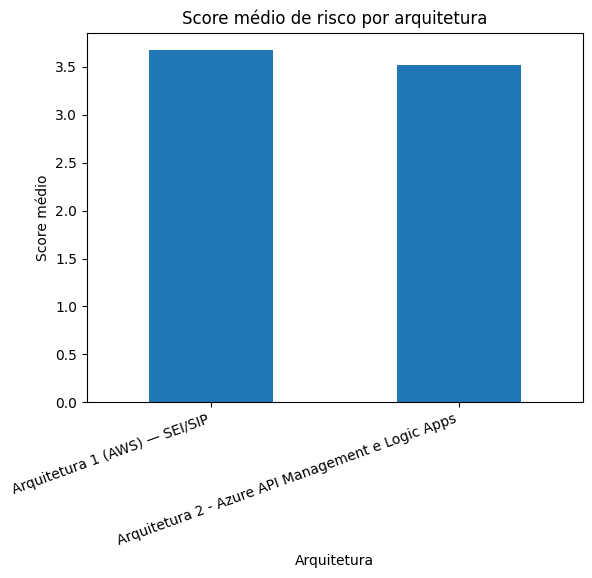

<Figure size 640x480 with 0 Axes>

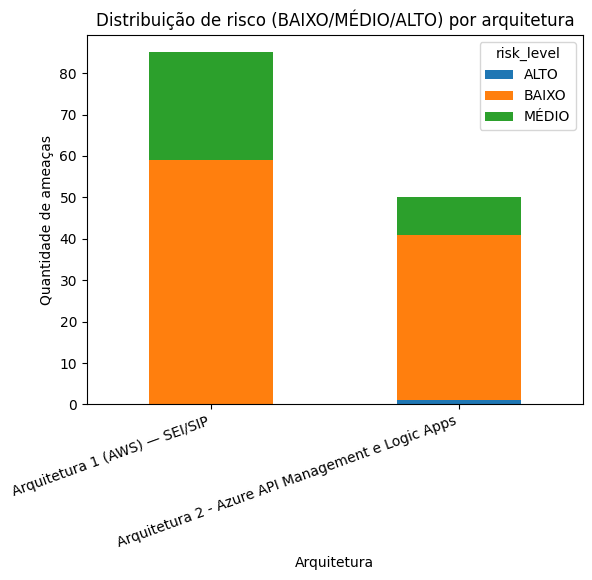

In [20]:
import matplotlib.pyplot as plt

# 1) Média de risco por arquitetura
avg_scores = df_all.groupby("system")["risk_score"].mean().sort_values(ascending=False)
plt.figure()
avg_scores.plot(kind="bar")
plt.title("Score médio de risco por arquitetura")
plt.ylabel("Score médio")
plt.xlabel("Arquitetura")
plt.xticks(rotation=20, ha="right")
plt.show()

# 2) Distribuição de níveis de risco por arquitetura
dist_levels = (
    df_all.groupby(["system","risk_level"])
    .size()
    .unstack(fill_value=0)
)

plt.figure()
dist_levels.plot(kind="bar", stacked=True)
plt.title("Distribuição de risco (BAIXO/MÉDIO/ALTO) por arquitetura")
plt.ylabel("Quantidade de ameaças")
plt.xlabel("Arquitetura")
plt.xticks(rotation=20, ha="right")
plt.show()

## 10) Exportar CSV

In [21]:
# CSV consolidado
df_all.to_csv("threats_consolidated.csv", index=False, encoding="utf-8")

# CSV separados
df_aws.to_csv("threats_aws.csv", index=False, encoding="utf-8")
df_azure.to_csv("threats_azure.csv", index=False, encoding="utf-8")

print("OK! CSVs gerados:")
print("- threats_consolidated.csv")
print("- threats_aws.csv")
print("- threats_azure.csv")

OK! CSVs gerados:
- threats_consolidated.csv
- threats_aws.csv
- threats_azure.csv


In [22]:
print("Modelo STRIDE aplicado com sucesso às duas arquiteturas.")

Modelo STRIDE aplicado com sucesso às duas arquiteturas.
